Importación de los módulos a usar en el taller

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import re
from smart_open import open
import linecache

# La librería nltk está disponible en el entorno de ejecución
# Importe otros módulos que necesite aquí. De no necesitarlo eliminar el "raise"
# para que la celda no genere error
# your code here
#raise NotImplementedError

# 1. Exploración del dataset y procesamiento del corpus

El dataset a utilizar fue tomado originalmente de Kaggle, y consiste en una serie de noticias falsas y verdaderas en inglés que para el propósito de este taller se mezclaron y se dejaron el 80% de las noticias para el entrenamiento de los modelos, y el 20% restante para la evaluación de los mismos.

El dataset original puede descargarse [aquí](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset?resource=download).

Primero, exploremos el contenido del dataset:

In [2]:
with open('fake_news_dataset/train.txt', 'r') as f:
    i = 0
    for line in f:
        i += 1
        print(line)
        
        if i == 10:
            break

Confusing different policies and different ideologies defines the modern Democratic Party Whether it s on domestic or foreign policy, you can count on the Democrats to confuse the heck out of the American people Andrew McCarthy says it best in his National Review column,  Democrats Know the Election Was Legitimate but Persist in a Dangerous Fraud.  Andy reminds us of the Democrats  180 on  accepting the results of the election. Horrifying!  inveighed an indignant Hillary Clinton at the last presidential debate, less than three weeks before Election Day. What so horrified her? Donald Trump s refusal to pledge that he would accept the legitimacy of the election.Trump speculated that the electoral process could be rigged. Until he saw how it played out, the Republican nominee said, he could not concede that the result would be on the up-and-up. *** A flabbergasted Clinton responded that she was shocked   horrified!   to hear Trump  talking down our democracy.  This was a top theme in her 

Cada línea de documentos corresponde al contenido textual de una noticia.

## 1.1 Ejercicio 1: Procese el texto de cada noticia

En este ejercicio usted debe completar el cuerpo de la función `process_text`, esta función tiene como objetivo procesar y tokenizar el texto para entrenar modelos de lenguaje de n-gramas.

Como entrada de la función usted recibirá el texto correspondiente a una noticia y deberá procesarlo y tokenizarlo según las indicaciones dadas en el docstring de la función.

**Importante**: Trate de usar expresiones regulares en la mayoría de su implementación para mejorar la eficiencia de la misma.

In [42]:
def process_text(text: str) -> "list[str]":
    """
    Esta función recibe un texto, el cual es procesado y tokenizado, para luego retornar una lista de palabras.

    Las etapas de procesamiento mínimamente necesarias son:
    - Transformación a minúsculas.
    - Eliminación de dígitos mezclados con letras.
    - Caracteres especiales o de puntuación se tratan como tokens separados.
    - Dígitos separados de letras se transforman al token <NUM>.
    - Se agregan los tokens <START> y <END> al inicio y final de la lista de palabras.

    Args:
        text (str): Texto a procesar.

    Returns:
        list[str]: Lista de palabras.

    Ejemplos:
    >>> process_text("I'm a super computer!")
    ['<START>', 'i', "'", 'm', 'a', 'super', 'computer', '!', '<END>']
    >>> process_text("I'm 35 years5 4old he43llo")
    ['<START>', 'i', "'", 'm', '<NUM>', 'years', 'old', 'hello', '<END>']
    >>> process_text("this, is an example. asd@asd.com")
    ['<START>', 'this', ',', 'is', 'an', 'example', '.', 'asd', '@', 'asd', '.', 'com', '<END>']
    """
    # Implemente el cuerpo de la función guíandose por la documentación de la función provista
    ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
    # your code here
    text = text.lower()
    text = re.sub(r'\b[a-z0-9]*\d+[a-z0-9]*\b', lambda m: re.sub(r'\d+', '', m.group()) if any(c.isalpha() for c in m.group()) else m.group(), text)
    text = re.sub(r'([^a-z0-9\s])', r' \1 ', text)
    text = re.sub(r'\b\d+\b', '<NUM>', text)
    tokens = text.split()
    tokens = ['<START>'] + tokens + ['<END>']
    return tokens
    
    #raise NotImplementedError
    ## FIN DE IMPLEMENTACIÓN (NO MODIFICAR DESPUÉS ESTA LÍNEA)

# Pruebe su implementación (puede probar con otros ejemplos):
print(process_text("I'm a super 4computer!"))

['<START>', 'i', "'", 'm', 'a', 'super', 'computer', '!', '<END>']


## 1.1 Se crea la clase Corpus para iterar y procesar el dataset

Esta clase nos va a permitir iterar de manera eficiente por el corpus, y aplicar el procesamiento y tokenización del texto a medida que se requiere cada uno de los documentos.
Esta clase hará uso de su implementación para procesar los artículos de noticias del dataset.

In [4]:
class Corpus:
    """Clase que permite leer un archivo de texto línea por línea y procesarla recibiendo como entrada la ruta del archivo."""
    def __init__(self, path: str):
        """
        La clase se inicializa con la ruta del archivo de texto que se desea utilizar como corpus. Cada línea del archivo
        debe contener una oración.

        Args:
            path (str): Ruta del archivo de texto que se desea utilizar como corpus.
        """
        self.path = path

    def _preprocess(self, line: str) -> "list[str]":
        """
        Método que recibe una línea de texto y la preprocesa para tokenizarla y agregar los tokens de inicio y fin de la secuencia.

        Args:
            line (str): Línea de texto que se desea preprocesar.

        Returns:
            list[str]: Lista de tokens que representan una documento del corpus.
        """
        # Se llama a la función process_text para preprocesar la línea
        return process_text(line)

    def __iter__(self) -> "iter[list[str]]":
        """
        Método que permite iterar sobre el corpus línea por línea.

        Returns:
            Un objeto iterable con la lista de tokens por documento del corpus.
        """
        with open(self.path, 'r') as f:
            for line in f:
                yield self._preprocess(line)

    def __len__(self) -> int:
        """
        Método que permite obtener la cantidad de líneas que contiene el corpus.
        """
        with open(self.path, 'r') as f:
            return sum(1 for _ in f)
        
    def __getitem__(self, index: int) -> "list[str]":
        """
        Método que permite obtener una línea específica del corpus.

        Args:
            index (int): Índice de la línea que se desea obtener.

        Returns:
            list: Lista de tokens que representan un documento del corpus.
        """
        # Se obtiene la línea del archivo de texto
        line = linecache.getline(self.path, index + 1)

        # Se preprocesa la línea
        return self._preprocess(line)

# Se crea una instancia de la clase Corpus
corpus = Corpus('fake_news_dataset/train.txt')
print(f'El corpus contiene {len(corpus):,} documentos.')

El corpus contiene 35,432 documentos.


Al momento de iterar por cada uno de los documentos corpus se aplica el procesamiento de texto implementado, por lo que puede ver el resultado de su implementación en un ejemplo real de corpus de entrenamiento:

In [5]:
# Puede probar distintos índices si lo desea
corpus[5]

['<START>',
 '(',
 'reuters',
 ')',
 '-',
 'u',
 '.',
 's',
 '.',
 'senate',
 'democratic',
 'leader',
 'chuck',
 'schumer',
 'on',
 'sunday',
 'demanded',
 'that',
 'president',
 'donald',
 'trump',
 'reverse',
 'an',
 'executive',
 'order',
 'targeting',
 'immigration',
 'from',
 'seven',
 'predominantly',
 'muslim',
 'countries',
 ',',
 'saying',
 'it',
 'makes',
 'the',
 'united',
 'states',
 'appear',
 '“',
 'less',
 'humanitarian',
 ',',
 'less',
 'safe',
 ',',
 'less',
 'american',
 '.',
 '”',
 '“',
 'it',
 'must',
 'be',
 'reversed',
 'immediately',
 ',',
 'and',
 'democrats',
 'are',
 'going',
 'to',
 'introduce',
 'legislation',
 'to',
 'overturn',
 'it',
 ',',
 '”',
 'schumer',
 'said',
 'in',
 'new',
 'york',
 '.',
 'schumer',
 'also',
 'said',
 'he',
 'had',
 'been',
 'told',
 'by',
 'u',
 '.',
 's',
 '.',
 'homeland',
 'security',
 'secretary',
 'john',
 'kelly',
 'that',
 '<',
 'N',
 'U',
 'M',
 '>',
 'people',
 'now',
 'detained',
 'at',
 'u',
 '.',
 's',
 '.',
 'airpor

# 2. Construcción del vocabulario

## 2.1 Construcción del vocabulario con el corpus de entrenamiento
En esta sección vamos a construir el vocabulario para el corpus de entrenamiento, esto nos permitirá definir que tokens vamos a dejar por fuera del vocabulario, y también nos dará visibilidad sobre los datos que disponemos para el entrenamiento de los modelos.

In [6]:
# Diccionario que almacenará el vocabulario
vocabulary = {}
# Iterar por cada documentos del corpus
for doc in corpus:
    # Iterar por cada token en el documento
    for token in doc:
        # Agregar el token al vocabulario y aumentar su frecuencia
        vocabulary[token] = vocabulary.get(token, 0) + 1

print(f'El corpus tiene un vocabulario de {len(vocabulary):,} tokens.')

El corpus tiene un vocabulario de 105,201 tokens.


Veamos algunos de los tokens más y menos frecuentes del corpus de entrenamiento:

In [7]:
# Se ordena el vocabulario de acuerdo a la frecuencia de los tokens en orden descendente
sorted_vocabulary = sorted(vocabulary.items(), key=lambda x: x[1], reverse=True)

print(f'Los 10 tokens más frecuentes son: {sorted_vocabulary[:10]}')
print(f'Los 10 tokens menos frecuentes son: {sorted_vocabulary[-10:]}')

Los 10 tokens más frecuentes son: [('the', 821454), ('.', 753548), (',', 726665), ('to', 429577), ('of', 353817), ('a', 330941), ('and', 327040), ('in', 282473), ('s', 227960), ('<', 203228)]
Los 10 tokens menos frecuentes son: [('besakih', 1), ('tyroleans', 1), ('tyrolean', 1), ('arno', 1), ('kompatscher', 1), ('germophobe', 1), ('warfield', 1), ('playpen', 1), ('wlkurcs', 1), ('renominate', 1)]


Ahora grafiquemos la distribución de las frecuencias de los tokens:

Text(0, 0.5, 'Number of words')

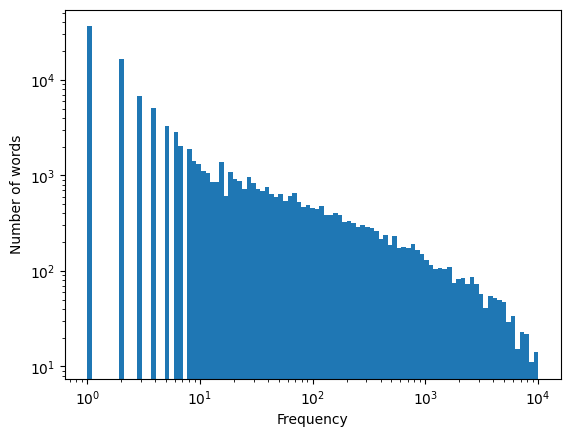

In [8]:
# Tomar la frecuencia de cada token
frequencies = list(vocabulary.values())

# Graficar el histograma de las frecuencias en escala logarítmica
plt.hist(frequencies, bins=np.logspace(0, 4, 100))
plt.gca().set_xscale("log")
plt.gca().set_yscale("log")
plt.xlabel('Frequency')
plt.ylabel('Number of words')

## 2.2. Tokens fuera del vocabulario

Eliminemos los tokens con frecuencia única para reservar una probabilidad de ocurrencia para las palabras fuera del vocabulario.

In [9]:
# Set con los tokens que se eliminarán
tokens_to_unknows = set()

# Iterar por cada token en el vocabulario
for token in sorted_vocabulary:
    # Si el token tiene una única ocurrencia en el corpus
    if token[1] == 1:
        # Agregar el token al set de tokens a eliminar
        tokens_to_unknows.add(token[0])

        # Eliminar el token del vocabulario
        del vocabulary[token[0]]

print(f'{len(tokens_to_unknows):,} tokens con una única ocurrencia en el corpus.')

36,400 tokens con una única ocurrencia en el corpus.


Se crea la clase `Corpus_with_unks` para transformar las palabras fuera del vocabulario del corpus de entrenamiento:

In [10]:
class Corpus_with_unks(Corpus):
    def __init__(self, dataset, unks:"list[str]"):
        """
        Clase para crear un corpus de texto iterable

        Args:
            path (int): Ubicación del archivo de texto a usar como corpus
            unks (list[str]): Listado de tokens a transformar a <UNK>
        """
        super().__init__(dataset)
        self.unks = unks

    def _preprocess(self, line: str):
        """
        Realiza procesamiento de texto y tokenización del texto recibido. También transforma los tokens previamente definidos a <UNK>.

        Args:
            line (str): Texto a procesar y tokenizar.

        Returns:
            list[str]: Lista de tokens procesados.
        """
        return [token if token not in self.unks else '<UNK>' for token in super()._preprocess(line)]

corpus_with_unks = Corpus_with_unks('fake_news_dataset/train.txt', tokens_to_unknows)

Observe el resultado de uno de los documentos bajo el procesamiento aplicado por la clase `Corpus_with_unks`:

In [11]:
# Puede probar distintos índices si lo desea
corpus_with_unks[0]

['<START>',
 'confusing',
 'different',
 'policies',
 'and',
 'different',
 'ideologies',
 'defines',
 'the',
 'modern',
 'democratic',
 'party',
 'whether',
 'it',
 's',
 'on',
 'domestic',
 'or',
 'foreign',
 'policy',
 ',',
 'you',
 'can',
 'count',
 'on',
 'the',
 'democrats',
 'to',
 'confuse',
 'the',
 'heck',
 'out',
 'of',
 'the',
 'american',
 'people',
 'andrew',
 'mccarthy',
 'says',
 'it',
 'best',
 'in',
 'his',
 'national',
 'review',
 'column',
 ',',
 'democrats',
 'know',
 'the',
 'election',
 'was',
 'legitimate',
 'but',
 'persist',
 'in',
 'a',
 'dangerous',
 'fraud',
 '.',
 'andy',
 'reminds',
 'us',
 'of',
 'the',
 'democrats',
 '<',
 'N',
 'U',
 'M',
 '>',
 'on',
 'accepting',
 'the',
 'results',
 'of',
 'the',
 'election',
 '.',
 'horrifying',
 '!',
 '<UNK>',
 'an',
 'indignant',
 'hillary',
 'clinton',
 'at',
 'the',
 'last',
 'presidential',
 'debate',
 ',',
 'less',
 'than',
 'three',
 'weeks',
 'before',
 'election',
 'day',
 '.',
 'what',
 'so',
 'horrified'

# 3. Implementación de modelos de lenguaje con n-gramas

En esta sección realizaremos el entrenamiento de los modelos de n-gramas. Adicionalmente, vamos a crear la clase `NGramModel` como un contenedor de las funciones que necesitamos para entrenar y evaluar el modelo de lenguaje. Vamos a construir cada una de estas funciones de manera independiente.

## 3.1. Ejercicio 2: Implementar el entrenamiento de un modelo de n-gramas

Para este ejercicio vamos a implementar el entrenamiento de los modelos de n-gramas. Para ello vamos a completar el cuerpo de la función `_train_ngram_model`, en donde recibimos como argumento el corpus, y el número de n gramas, y debemos retornar los componentes principales del modelo entrenado:
* Diccionario con las frecuencias de los n-gramas del corpus.
* Diccionario con las frecuencias de los (n-1)-gramas del corpus.
* Set el vocabulario del corpus.

Los primeros dos componentes son necesarios para calcular la probabilidad de secuencias de texto, y el último componente solo se usa si se aplica suavizado de Laplace.

**Importante**: Se debe tratar de construir los 3 componentes mencionados con una sola iteración por el corpus para mejorar los tiempos de entrenamiento del modelo.

In [18]:
def _train_ngram_model(corpus: iter, n: int):
    """
    Función para entrenar el modelo de n-gramas.

    Args:
        corpus (iter): Corpus de texto iterable.
        n (int): Orden del modelo de n-gramas.

    Returns:
        tuple: 
            - (set) tokens únicos observados en el corpus
            - (dic) diccionario con la frecuencia de cada n-grama observado en el corpus. Las llaves son tuplas de n tokens y su valor es la frecuencia.
            - (dic) diccionario con la frecuencia de cada contexto observado en el corpus. Las llaves son tuplas de n-1 tokens y su valor es la frecuencia.

    Ejemplo:
    >>> corpus = [['hello' , 'world'], ['hello' , 'world'], ['hello' , 'there']]
    >>> _train_ngram_model(corpus, 2)
    ({'hello', 'there', 'world'},
    {('hello', 'world'): 2, ('hello', 'there'): 1},
    {('hello',): 3, ('world',): 2, ('there',): 1})
    >>> corpus = [['hello' , 'world'], ['hello' , 'world'], ['hello' , 'there']]
    >>> _train_ngram_model(corpus, 1)
    ({'hello', 'there', 'world'},
    {('hello',): 3, ('world',): 2, ('there',): 1},
    {(): 6})
    """
    # Complete el cuerpo de función guíandose por la documentación de la función provista
    ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
    # your code here
    tokens_unicos = set()
    n_grams_dict = {}
    context_dict = {}
    context_length = n - 1
    for sentence in corpus:
        #Vocabuilario
        for token in sentence:
            tokens_unicos.add(token)
        #Caso unigramas
        if n == 1:
            context_dict[()] = context_dict.get((), 0) + len(sentence)
            for token in sentence:
                ngram = (token,)
                n_grams_dict[ngram] = n_grams_dict.get(ngram, 0) + 1
        #Caso bigramas y mayores
        else:
            for i in range(len(sentence)):
                # Obtener contexto
                context = tuple(sentence[i : i + context_length])
                
                # Solo procesamos si el contexto tiene el tamaño correcto
                if len(context) == context_length:
                    context_dict[context] = context_dict.get(context, 0) + 1
                    
                    # Obtener n-grama (contexto + palabra siguiente)
                    if i + context_length < len(sentence):
                        ngram = tuple(sentence[i : i + n])
                        n_grams_dict[ngram] = n_grams_dict.get(ngram, 0) + 1

    return tokens_unicos, n_grams_dict, context_dict
    #raise NotImplementedError
    ## FIN DE IMPLEMENTACIÓN (NO MODIFICAR DESPUÉS ESTA LÍNEA)

# Pruebe su implementación (puede probar con otros ejemplos):
corpus = [['hello' , 'world'], ['hello' , 'world'], ['hello' , 'there']]
_train_ngram_model(corpus, 2)

({'hello', 'there', 'world'},
 {('hello', 'world'): 2, ('hello', 'there'): 1},
 {('hello',): 3, ('world',): 2, ('there',): 1})

## 3.2. Ejercicio 3: Cálculo de la probabilidad de un token

En este ejercicio se quiere crear la funcionalidad necesaria para poder calcular la probabilidad de ocurrencia de un token según el modelo de n-gramas que se esté usando.

$P(w_i|w_{i-n}..w_{i-1})$, en donde $w_i$ representa el token para el cual queremos calcular la probabilidad, y esta probabilidad estaría condicionada en el número de tokens de contexto (n-1) que use nuestro modelo. Recordando lo visto en los materiales de la semana y en el tutorial, aplicando el suavizado de Laplace la proabilidad de ocurrencia del token condicionado en su contexto es igual a:

$P(w_i|w_{i-n}...w_{i-1}) = \frac{\text{count}(w_{i-n}, ..., w_i)+1}{\text{count}(w_{i-n}, w_{i-1})+V}$

Usted debe completar el cuerpo de la función `_probability_of_token` en donde debe calcular la probabilidad de ocurrencia del último token de la secuencia según los diccionarios de n-gramas y de contexto de un modelo previamente entrenado. Adicionalmente, debe poderse calcular la probabilidad con y sin suavizado de Laplace.

In [28]:
def _probability_of_token(sequence: "list[str]", n: int, n_grams_dict: dict, context_dict: dict, vocab_size: int,laplace_smoothing: bool = False) -> float:
    """
    Método para calcular la probabilidad de ocurrencia del último token de la secuencia.
    Importante: Cuando no se aplica suavizado de Laplace y el token no se encuentra en el diccionario de contexto, se espera que la función genere un error al no poderse dividir por 0.

    Args:
        sequence (list[str]): Listado de tokens que conforman la secuencia.
        n_grams_dict (dict): Diccionario con la frecuencia de n-gramas.
        context_dict (dict): Diccionario con la frecuencia de contextos (n-1 gramas).
        vocab_size (int): Tamaño del vocabulario.
        laplace_smoothing (bool): Indica si se debe aplicar suavizado de Laplace. Por defecto es False.

    Returns:
        float: Probabilidad de ocurrencia del último token de la secuencia.

    Ejemplos:
    >>> n_grams_dict = {('hello', 'world'): 2, ('hello', 'there'): 1}
    >>> context_dict = {('hello',): 3, ('world',): 2, ('there',): 1}
    >>> _probability_of_token(['hello', 'world'], n_grams_dict, context_dict, 3)
    0.6666666666666666
    >>> _probability_of_token(['hello', 'world'], 2, n_grams_dict, context_dict, vocab_size=3, laplace_smoothing=True)
    0.5
    """
    # Complete el cuerpo de función guíandose por la documentación de la función provista
    ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
    # your code here
    
    n_gram = tuple(sequence[-n:])
    context = tuple(sequence[-n : -1]) if n > 1 else ()
    count_ngram = n_grams_dict.get(n_gram, 0)
    count_context = context_dict.get(context, 0)
    if laplace_smoothing:
        # Fórmula: (Conteo + 1) / (Contexto + Vocabulario)
        prob = (count_ngram + 1) / (count_context + vocab_size)
    else:
        # Fórmula: Conteo / Contexto
        # Nota: Si count_context es 0, Python lanzará ZeroDivisionError (comportamiento esperado)
        prob = count_ngram / count_context

    return prob
    #raise NotImplementedError
    ## FIN DE IMPLEMENTACIÓN (NO MODIFICAR DESPUÉS ESTA LÍNEA)

# Pruebe su implementación (puede probar con otros ejemplos):
n_grams_dict = {('hello', 'world'): 2, ('hello', 'there'): 1}
context_dict = {('hello',): 3, ('world',): 2, ('there',): 1}
_probability_of_token(['hello', 'world'], 2, n_grams_dict, context_dict, vocab_size=3, laplace_smoothing=False)

0.6666666666666666

## 3.3. Cálculo de la métrica de perplejidad

En este sección vamos a implementar el cálculo de la métrica de perplejidad para una secuencia de texto.

Recuerde que la fórmula para calcular la perplejidad es la siguiente:

$PP(W)=(\prod_{i=1}^T P(w_i|w_{i-n}...w_{i-1}))^{-1/T}$, en donde $T$ es el número de n-gramas presentes en la secuencia. Es importante resaltar que para el cálculo de la perplejidad solo se toman en cuenta los n-gramas presentes en la secuencia y no el número de tokens. Es decir, para la secuencia $s$ "hola que tal", si se usa un modelo de bigramas la perplejidad se calcula como:

$PP(s) = (P(\text{que}|\text{hola})*P(\text{tal}|\text{que}))^{-1/2}$

Debido a que las secuencias pueden ser largas y las probabilidades de cada n-grama suelen ser muy bajas, se utiliza la siguiente fórmula con el mismo ejemplo de arriba:

$PP(s) = P(\text{que}|\text{hola})^{-1/2}*P(\text{tal}|\text{que})^{-1/2}$

In [29]:
def _perplexity(sequence: iter, n: int, n_grams_dict: dict, context_dict: dict, vocab_size: int,laplace_smoothing: bool = False) -> float:
    """
    Método para calcular la perplejidad de una secuencia de tokens.

    Args:
        sequence (iter): Secuencia de tokens de la cual se desea calcular la perplejidad.
        n (int): Orden del modelo de n-gramas.
        n_grams_dict (dict): Diccionario con la frecuencia de n-gramas.
        context_dict (dict): Diccionario con la frecuencia de contextos (n-1 gramas).
        vocab_size (int): Tamaño del vocabulario.
        laplace_smoothing (bool): Indica si se debe aplicar suavizado de Laplace. Por defecto es False.

    Returns:
        float: Perplejidad de la secuencia.

    Ejemplos:
    >>> n_grams_dict = {('hello', 'world'): 2, ('hello', 'there'): 1, ('world', '!'): 1}
    >>> context_dict = {('hello',): 3, ('world',): 2, ('there',): 1, ('!',): 1}
    >>> perplexity(['hello', 'world'], 2, n_grams_dict, context_dict, 3)
    1.5
    >>> perplexity(['hello', 'world', '!'], 2, n_grams_dict, context_dict, 3, laplace_smoothing=True)
    2.23606797749979
    """
    pp = 1

    if len(sequence) < n:
        raise ValueError(f'La secuencia debe tener al menos {n} tokens.')
    
    n_grams_count = len(sequence) - n + 1

    for i in range(n -1, len(sequence)):
        pp *= (_probability_of_token(sequence[:i+1], n, n_grams_dict, context_dict, vocab_size, laplace_smoothing)) ** (-1/n_grams_count)
    return pp

n_grams_dict = {('hello', 'world'): 2, ('hello', 'there'): 1, ('world', '!'): 1}
context_dict = {('hello',): 3, ('world',): 2, ('there',): 1, ('!',): 1}
_perplexity(['hello', 'world', '!'], 2, n_grams_dict, context_dict, 3, laplace_smoothing=True)

2.23606797749979

## 3.4. Ejercicio 4: Generación de texto

Como último ejercicio complete el cuerpo de la función `_generate_text` para generar texto a través de los modelos de n-gramas.

Para realizar su implementación, tenga en cuenta que:
* La semilla de tokens con la que se llame su función siempre va a tener al menos n-1 tokens. No debe preocuperse por manejar este escenario.
* Se elige como siguiente token el n-grama con la probabilidad más alta.
* Se detiene la generación de texto cuando se alcanza la longitud máxima o se encuentra el token `<END>` (en este último caso agregar el token `<END>` al final de la secuencia).
* El texto generado debe ser una cadena de texto con los tokens separados por un espacio.


In [30]:
def _generate_text(seed: iter, n: int, n_grams_dict: dict, context_dict: dict, vocabulary: set, laplace_smoothing: bool = False, max_length = 100) -> str:
    """
    Método para generar texto a partir de una secuencia de tokens semilla.
    La semilla debe tener al menos n-1 tokens para generar el siguiente token usando el modelo de n-gramas.
    Se elige como siguiente token el n-grama con la probabilidad más alta.
    Se detiene la generación de texto cuando se alcanza la longitud máxima o se encuentra el token '<END>' (en este último caso agregar el token <END> al final de la secuencia).
    El texto generado debe ser una cadena de texto con los tokens separados por un espacio.

    Args:
        seed (iter): Secuencia de tokens semilla para la generación de texto.
        n (int): Orden del modelo de n-gramas.
        n_grams_dict (dict): Diccionario con la frecuencia de n-gramas.
        context_dict (dict): Diccionario con la frecuencia de contextos (n-1 gramas).
        vocabulary (set): Set con el vocabulario del corpus.
        laplace_smoothing (bool): Indica si se debe aplicar suavizado de Laplace. Por defecto es False.
        max_length (int): Máxima cantidad de tokens de la secuencia generada (incluyendo los tokens semilla).

    Returns:
        str: Secuencia de texto generada (incluyendo los tokens semilla).

    Ejemplos:
    >>> n_grams_dict = {('hello', 'world'): 2, ('hello', 'there'): 1, ('world', '!'): 1, ('there', '!'): 1, ('!', '<END>'): 2}
    >>> context_dict = {('hello',): 3, ('world',): 2, ('there',): 1, ('!',): 2, ('<END>',): 2}
    >>> vocabulary = {'hello', 'world', 'there', '!', '<END>'}
    >>> generate_text(['hello', 'world'], 2, n_grams_dict, context_dict, vocabulary, max_length=10)
    'hello world ! <END>'
    """
    # Complete el cuerpo de función guíandose por la documentación de la función provista
    ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
    # your code here
    generated_sequence = list(seed)
    vocab_size = len(vocabulary)
    
    while len(generated_sequence) < max_length:
        last_token = generated_sequence[-1]
        if last_token == '<END>':
            break
        best_token = None
        max_prob = -1.0 
        for token in vocabulary:
            current_prob = _probability_of_token(generated_sequence + [token], n, n_grams_dict, context_dict, vocab_size, laplace_smoothing)
            if current_prob > max_prob:
                max_prob = current_prob
                best_token = token
        if best_token:
            generated_sequence.append(best_token)
        else:
            break
    return " ".join(generated_sequence)
    #raise NotImplementedError
    ## FIN DE IMPLEMENTACIÓN (NO MODIFICAR DESPUÉS ESTA LÍNEA)

# Pruebe su implementación (puede probar con otros ejemplos):
n_grams_dict = {('hello', 'world'): 2, ('hello', 'there'): 1, ('world', '!'): 1, ('there', '!'): 1, ('!', '<END>'): 2}
context_dict = {('hello',): 3, ('world',): 2, ('there',): 1, ('!',): 2, ('<END>',): 2}
vocabulary = {'hello', 'world', 'there', '!', '<END>'}
_generate_text(['hello', 'world'], 2, n_grams_dict, context_dict, vocabulary, max_length=10)

'hello world ! <END>'

## 3.5. Implementación de la clase `NGramModel`

Ahora implementaremos la clase `NGramModel` para abstraer todas las funcionalidades constuidas en una única interfaz. Además de las funciones implementadas anteriormente se agregaron métodos para calcular la probabilidad de una secuencia de tokens, y para evaluar fácilmente la perplejidad de un dataset completo.

In [31]:
class NGramModel:
    def __init__(self, n: int):
        """
        Clase para crear un modelo de n-gramas.

        Args:
            n (int): Número de n-gramas a usar.
        """
        self.n = n
        self.n_grams = {}
        self.context = {}
        self.vocabulary = set()
        self.vocab_size = 0

    def train(self, corpus: iter):
        """
        Método para entrenar el modelo de n-gramas.

        Args:
            corpus (iter): Corpus de texto iterable.
        """
        # Se entrena el modelo de n-gramas mediante la función implementada anteriormente
        vocab, n_grams, context = _train_ngram_model(corpus, self.n)

        self.vocabulary = vocab
        self.vocab_size = len(vocab)
        self.n_grams = n_grams
        self.context = context

    def probability_of_token(self, sequence: iter, laplace_smoothing: bool = False) -> float:
        """
        Método para calcular la probabilidad de un token con n-1 tokens de contexto.

        Args:
            tokens (iter): Secuencia de tokens de la cual se desea calcular la probabilidad.

        Returns:
            float: Probabilidad de ocurrencia del último token de la secuencia.
        """
        # Se calcula la probabilidad del token mediante la función implementada anteriormente
        return _probability_of_token(sequence, self.n, self.n_grams, self.context, self.vocab_size, laplace_smoothing)
    
    def probability_of_sequence(self, sequence: iter, laplace_smoothing: bool = False) -> float:
        """
        Método para calcular la probabilidad de una secuencia de tokens.

        Args:
            sequence (iter): Secuencia de tokens de la cual se desea calcular la probabilidad.

        Returns:
            float: Probabilidad de ocurrencia de la secuencia.
        """
        log_p = 0

        if len(sequence) < self.n:
            raise ValueError(f'La secuencia debe tener al menos {self.n} tokens.')

        for i in range(self.n -1, len(sequence)): # Solo se toman en cuenta en el cálculo, los n-gramas de la secuencia
            log_p += np.log(self.probability_of_token(sequence[:i+1], laplace_smoothing))
        return np.exp(log_p)
    
    def eval_corpus(self, corpus: iter, laplace_smoothing: bool = False) -> float:
        """
        Método para evaluar la perplejidad del modelo para un corpus de texto.

        Args:
            corpus (iter): Corpus de texto iterable.

        Returns:
            float: Perplejidad del modelo para el corpus.
        """
        accum_pp = 1
        sequences = len(corpus)

        for doc in corpus:
            # Si el documento es muy corto para calcular la perplejidad con el modelo, se ignora
            if len(doc) < self.n:
                sequences -= 1
                continue

            accum_pp *= _perplexity(doc, self.n, self.n_grams, self.context, self.vocab_size, laplace_smoothing) ** (1/sequences)

        return accum_pp
    
    def perplexity(self, sequence: iter, laplace_smoothing: bool = False) -> float:
        """
        Método para calcular la perplejidad de una secuencia de tokens.

        Args:
            sequence (iter): Secuencia de tokens de la cual se desea calcular la perplejidad.

        Returns:
            float: Perplejidad de la secuencia.
        """ 
        # Se calcula la perplejidad de la secuencia mediante la función implementada anteriormente
        return _perplexity(sequence, self.n, self.n_grams, self.context, self.vocab_size, laplace_smoothing)
    
    def generate_text(self, seed: iter, laplace_smoothing: bool = False,  max_length: int = 100):
        """
        Método para generar texto a partir de un seed.

        Args:
            max_length (int): Longitud máxima del texto a generar.
            seed (iter): Secuencia de tokens de inicio.
        """
        # Se genera texto mediante la función implementada anteriormente
        return _generate_text(seed, self.n, self.n_grams, self.context, self.vocabulary, laplace_smoothing, max_length)

# 4. Entrenamiento de modelos de n-gramas

En esta sección realizamos el entrenamiento de los modelos de n-gramas con el corpus de entrenamiento.

Tenga en cuenta que el entrenamiento de cada uno de los modelos puede tardar varios minutos.

In [32]:
unigram_model = NGramModel(1)
unigram_model.train(corpus_with_unks)

In [33]:
bigram_model = NGramModel(2)
bigram_model.train(corpus_with_unks)

In [34]:
trigram_model = NGramModel(3)
trigram_model.train(corpus_with_unks)

# 5. Evaluación de los modelos de lenguaje con n-gramas

## 5.1. Limitaciones de la probabilidad como métrica de evaluación

Probemos la probabilidad asignada por cada uno de los modelos para una de las secuencias encontrada en el corpus de entrenamiento:

In [35]:
print(corpus_with_unks[0])
print('1-gram - P(s)=', unigram_model.probability_of_sequence(corpus_with_unks[0], laplace_smoothing=True))
print('2-gram - P(s)=',bigram_model.probability_of_sequence(corpus_with_unks[0], laplace_smoothing=True))
print('3-gram - P(s)=',trigram_model.probability_of_sequence(corpus_with_unks[0], laplace_smoothing=True))

['<START>', 'confusing', 'different', 'policies', 'and', 'different', 'ideologies', 'defines', 'the', 'modern', 'democratic', 'party', 'whether', 'it', 's', 'on', 'domestic', 'or', 'foreign', 'policy', ',', 'you', 'can', 'count', 'on', 'the', 'democrats', 'to', 'confuse', 'the', 'heck', 'out', 'of', 'the', 'american', 'people', 'andrew', 'mccarthy', 'says', 'it', 'best', 'in', 'his', 'national', 'review', 'column', ',', 'democrats', 'know', 'the', 'election', 'was', 'legitimate', 'but', 'persist', 'in', 'a', 'dangerous', 'fraud', '.', 'andy', 'reminds', 'us', 'of', 'the', 'democrats', '<', 'N', 'U', 'M', '>', 'on', 'accepting', 'the', 'results', 'of', 'the', 'election', '.', 'horrifying', '!', '<UNK>', 'an', 'indignant', 'hillary', 'clinton', 'at', 'the', 'last', 'presidential', 'debate', ',', 'less', 'than', 'three', 'weeks', 'before', 'election', 'day', '.', 'what', 'so', 'horrified', 'her', '?', 'donald', 'trump', 's', 'refusal', 'to', 'pledge', 'that', 'he', 'would', 'accept', 'the

Note como la probabilidad asignada por todos los modelos a la secuencia es 0, debido a que que el número es tan pequeño que no puede ser representado con precisión por Python. Ahora vea los resultados de la métrica de perplejidad para la misma secuencia:

In [36]:
print(corpus_with_unks[0])
print('1-gram - PP(s)=', unigram_model.perplexity(corpus_with_unks[0], laplace_smoothing=True))
print('2-gram - PP(s)=',bigram_model.perplexity(corpus_with_unks[0], laplace_smoothing=True))
print('3-gram - PP(s)=',trigram_model.perplexity(corpus_with_unks[0], laplace_smoothing=True))

['<START>', 'confusing', 'different', 'policies', 'and', 'different', 'ideologies', 'defines', 'the', 'modern', 'democratic', 'party', 'whether', 'it', 's', 'on', 'domestic', 'or', 'foreign', 'policy', ',', 'you', 'can', 'count', 'on', 'the', 'democrats', 'to', 'confuse', 'the', 'heck', 'out', 'of', 'the', 'american', 'people', 'andrew', 'mccarthy', 'says', 'it', 'best', 'in', 'his', 'national', 'review', 'column', ',', 'democrats', 'know', 'the', 'election', 'was', 'legitimate', 'but', 'persist', 'in', 'a', 'dangerous', 'fraud', '.', 'andy', 'reminds', 'us', 'of', 'the', 'democrats', '<', 'N', 'U', 'M', '>', 'on', 'accepting', 'the', 'results', 'of', 'the', 'election', '.', 'horrifying', '!', '<UNK>', 'an', 'indignant', 'hillary', 'clinton', 'at', 'the', 'last', 'presidential', 'debate', ',', 'less', 'than', 'three', 'weeks', 'before', 'election', 'day', '.', 'what', 'so', 'horrified', 'her', '?', 'donald', 'trump', 's', 'refusal', 'to', 'pledge', 'that', 'he', 'would', 'accept', 'the

La perplejidad al ser un promedio (geométrico) es una métrica que puede escalar según el tamaño de la frecuencia sin problemas de desbordamiento, por esta razón podemos evaluar el desempeño del modelo de lenguaje con el dataset de evaluación completo.

Para el caso de la secuencia de texto que usamos, la perplejidad nos indicaría que el modelo que está menos sorprendido de observar la secuencia de texto dada sería el modelo de unigramas, y por lo tanto sería el modelo que mejor se ajusta a la secuencia observada.

## 5.2. Evaluación de los modelos de n-gramas

Para evaluar los modelos de n-gramas, vamos a usar el 20% de los artículos de noticias que **no** se usaron en el entrenamiento de los modelos. Utilizaremos la métrica de perplejidad para evaluar el desempeño de los modelos entrenados.

En primera instancia, vamos a implementar la clase `EvalCorpus` para iterar por el set de evaluación y realizar la transformación de las palabras fuera del vocabulario.

In [37]:
class EvalCorpus(Corpus):
    def __init__(self, path: str, vocabulary:"list[str]"):
        """
        Clase para crear un corpus de texto iterable

        Args:
            path (int): Ubicación del archivo de texto a usar como corpus
            unks (list[str]): Listado de tokens a transformar a <UNK>
        """
        super().__init__(path)
        self.vocab = vocabulary

    def _preprocess(self, line: str):
        """
        Realiza procesamiento de texto y tokenización del texto recibido. También transforma los tokens previamente definidos en <UNK>.

        Args:
            line (str): Texto a procesar y tokenizar. 
        """
        return [token if token in self.vocab else '<UNK>' for token in super()._preprocess(line)]
    
eval_corpus = EvalCorpus('fake_news_dataset/test.txt', unigram_model.vocabulary)
print('El corpus de evaluación tiene', len(eval_corpus), 'documentos.')

El corpus de evaluación tiene 8835 documentos.


Veamos el desempeño de los modelos para la primera secuencia del set de evaluación

In [38]:
sample = eval_corpus[0] # Puede probar con otros índices si lo desea

print(sample)
print(unigram_model.perplexity(sample, laplace_smoothing=True))
print(bigram_model.perplexity(sample, laplace_smoothing=True))
print(trigram_model.perplexity(sample, laplace_smoothing=True))

['<START>', 'barack', 'obama', 'stutters', 'through', 'yet', 'another', 'jerky', 'moment', 'where', 'he', 'just', 'can', 't', 'zip', 'his', 'lips', ':', 'he', 's', 'the', 'president', 'who', 'just', 'won', 't', 'go', 'away', ':', 'some', ',', 'some', 'of', 'the', 'politics', 'we', 'see', ',', 'now', 'we', ',', 'we', 'thought', 'we', 'put', 'that', 'to', 'bed', '.', 'uh', '-', 'i', '-', 'uh', '-', 'mean', 'that', '-', 'uh', '-', 'that', 'folks', 'looking', 'fifty', 'years', 'back', '.', 'it', 's', 'the', 'st', 'century', '.', 'obama', 'really', 'was', 'the', 'most', 'divisive', 'potus', 'in', 'history', '.', 'it', 's', 'pretty', 'unbelievable', 'that', 'he', 's', 'now', 'claiming', 'trump', 'is', 'divisive', '.', 'this', 'made', 'us', 'think', 'of', '<UNK>', 'and', 'the', 'tactics', 'used', 'by', 'obama', 'in', 'the', 'past', 'to', 'divide', 'americans', ':', 'saul', 'alinsky', '<', 'N', 'U', 'M', '>', ':', 'accuse', 'your', 'opponent', 'of', 'what', 'only', 'you', 'are', 'doing', ',', 

Evaluación de la perplejidad en el set de evaluación:

In [39]:
print(f'1-gram - PP(S)={unigram_model.eval_corpus(eval_corpus, laplace_smoothing=True):,.2f}')
print(f'2-gram - PP(S)={bigram_model.eval_corpus(eval_corpus, laplace_smoothing=True):,.2f}')
print(f'3-gram - PP(S)={trigram_model.eval_corpus(eval_corpus, laplace_smoothing=True):,.2f}')

1-gram - PP(S)=936.36
2-gram - PP(S)=699.15
3-gram - PP(S)=5,032.74


Según la métrica de perplejidad, el modelo que mejor se ajusta al dataset de evaluación es el de bigramas.

## 5.3. Generación de texto

In [40]:
sample_seed = 'the president was in the'.split()

print(unigram_model.generate_text(sample_seed, laplace_smoothing=True, max_length=50))
print(bigram_model.generate_text(sample_seed, laplace_smoothing=True, max_length=50))
print(trigram_model.generate_text(sample_seed, laplace_smoothing=True, max_length=50))

the president was in the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
the president was in the united states . the united states . the united states . the united states . the united states . the united states . the united states . the united states . the united states . the united states . the united states . the united
the president was in the united states . the u . s . president donald trump s campaign . the u . s . president donald trump s campaign . the u . s . president donald trump s campaign . the u . s . president donald trump s


In [41]:
sample_seed = 'has been a lot of'.split() # Puede probar con otras semillas si lo desea

print(unigram_model.generate_text(sample_seed, laplace_smoothing=True, max_length=50))
print(bigram_model.generate_text(sample_seed, laplace_smoothing=True, max_length=50))
print(trigram_model.generate_text(sample_seed, laplace_smoothing=True, max_length=50))

has been a lot of the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
has been a lot of the united states . the united states . the united states . the united states . the united states . the united states . the united states . the united states . the united states . the united states . the united states . the
has been a lot of people who are not going to be a good thing . ” the official said . the u . s . president donald trump s campaign . the u . s . president donald trump s campaign . the u . s . president donald


# 6. Conclusiones

A pesar de que el modelo con mejor métrica de perplejidad es el de bigramas, este modelo no es el más óptimo para la tarea generación de texto al modelar únicamente la dependencia entre dos palabras. Por esta razón, es importante tener métricas de evaluación que evalúen el desempeño del modelo en las tareas en las cuales los vamos a utilizar.

Los modelos de n-gramas solo nos permiten modelar dependencias textuales de corto plazo debido a que la presición de la probabilidad asignada a los n-gramas está sujeta a la cantidad de ocurrencias exactas de la secuencia en el texto.

Por último, los modelos de n-gramas logran generar texto con cierta coherencia que respeta normas gramáticales, pero las secuencias de texto generadas están fuertemente ligadas al dominio del corpus de entrenamiento. Por ejemplo, los modelos entrenados anteriormente no generarían secuencias de texto relacionadas a un texto científico o a un cuento de niños.